# Visualizing Clustering

First, we're going to experiment with making a [dendrogram](https://en.wikipedia.org/wiki/Dendrogram) using the 
[Scipy dendrogram method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) and the [Scipy hierarchical clustering linking method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html).  An example of this is given by [this tutorial](https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/).

The cells below set up a two-dimensional dataset with overlapping clusters.  At the end, follow the tutorial to find clusters and set up a dendrogram!

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

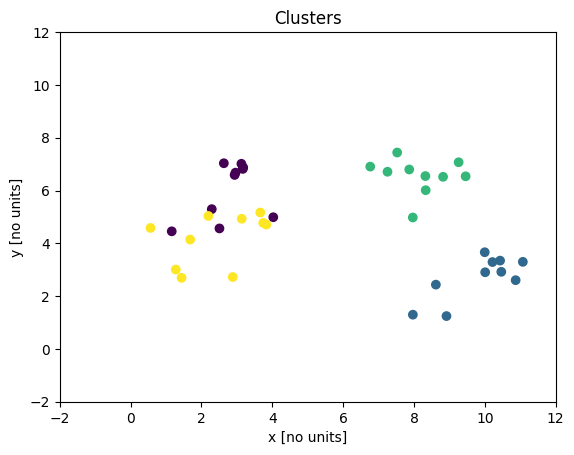

In [3]:
np.random.seed(12345678)

# lists for x and y coordinates of clusters, 
# as well as labels that have cluster numbers
x = []
y = []
cluster_labels = []

# number of clusters in dataset
n_clusters = 4

# points per cluster in dataset
n_pts_per_cluster = 10

# cluster distribution standard deviation size (arbitrary units - x and y limits are [0,10] in random number generation)
# sigma = 
sigma = 1.0


for this_cluster in range(n_clusters):
    ccx = 10*np.random.random()
    ccy = 10*np.random.random()

    for points in range(n_pts_per_cluster):
        x.append( ccx + np.random.normal(scale=sigma))
        y.append( ccy + np.random.normal(scale=sigma))
        cluster_labels.append(this_cluster)

plt.scatter(x,y,c=cluster_labels)
plt.xlim(-2,12)
plt.ylim(-2,12)
plt.title("Clusters")
plt.xlabel("x [no units]")
plt.ylabel("y [no units]")
plt.show()

## Now, let's make a dendrogram!

The lists ```x```, ```y```, and ```cluster_labels```, contain x positions, y positions, and cluster labels, respectively.  Follow along with [this tutorial](https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/) to create a dendrogram showing the relationships between the points generated above.  Do the relationships found by the clustering algorithm agree with the known relationships?  Why or why not?  And, as you change the size of the various parameters in the cluster generator (```sigma``` in particular) and rerun the notebook, do the results make sense?

**Important**: as you read through the tutorial, pay special attention to the dicussion that covers the information encodes in the "**Z matrix**" or "**linkage matrix**". Understanding the Z matrix is useful for understand how the tree is constructed.

In [15]:
# Put your code for making a dendogram here!
X = []
for i in range(len(x)):
    X.append([x[i], y[i]])

Z = linkage(X, "ward")

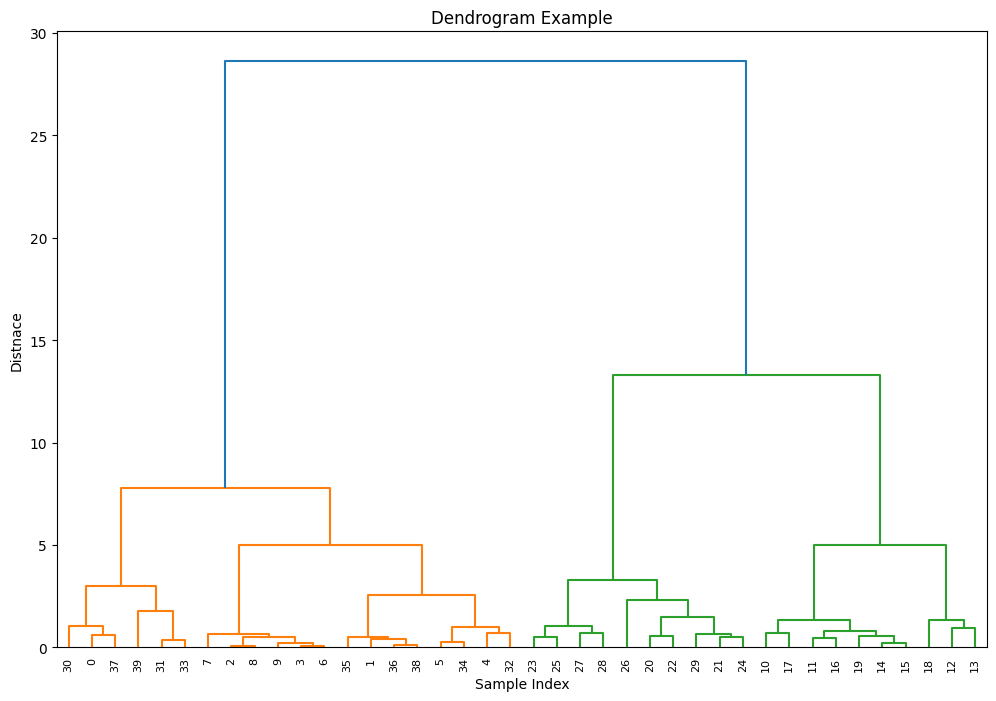

In [19]:
plt.figure(figsize=(12,8))
plt.xlabel("Sample Index")
plt.ylabel("Distnace")
plt.title("Dendrogram Example")
dendrogram(Z, leaf_rotation=90)
plt.show()

---
# Visualizing clustering in other ways

What if we wanted to make a [sunburst diagram](https://datavizcatalogue.com/methods/sunburst_diagram.html) to visualize the tree that we just made? We might be able to build something by parsing the tree heirarchy and using matplotlib's [polar axis plot](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_bar.html)

Using the example code from the matplotib documentation page (copied below) as inspiration, experiment with how you can change the position, size, and lengths of the wedges to see if you can make something that looks _something like_ a sunburst diagram. For example, you might be able to make something that looks like this:

<img src="https://i.imgur.com/erY9e3T.png">

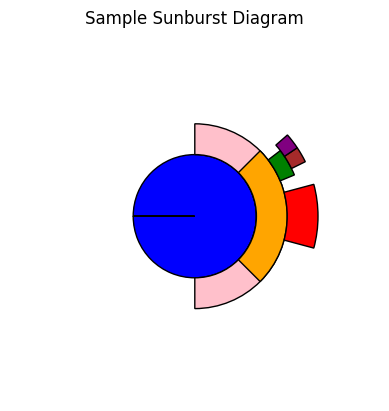

In [68]:
import numpy as np
import matplotlib.pyplot as plt

ax = plt.subplot(projection='polar')

start_angle = np.array([np.deg2rad(0), np.deg2rad(0), np.deg2rad(0), np.deg2rad(0),
               np.deg2rad(30), np.deg2rad(30), np.deg2rad(37.5)])

end_angle   = np.array([np.deg2rad(360), np.deg2rad(180), np.deg2rad(90), np.deg2rad(30),
               np.deg2rad(45), np.deg2rad(37.5), np.deg2rad(45)])

inner_r     = np.array([0, 2, 2, 3, 3, 3.5, 3.5])        
outer_r     = np.array([2, 3, 3, 4, 3.5, 4, 4])           

theta = start_angle
width = end_angle - start_angle
bottom = inner_r
height = outer_r - inner_r
colors = ["blue", "pink", "orange", "red", "green", "brown", "purple"]

ax.bar(theta, height, width=width, bottom=bottom, color=colors, edgecolor='black')

ax.set_ylim(0, 6)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.spines["polar"].set_visible(False)
ax.set_title("Sample Sunburst Diagram")
plt.show()

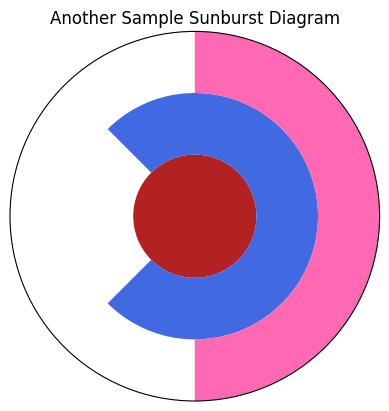

In [86]:
ax = plt.subplot(projection='polar')

ax.bar(np.deg2rad(0), 1, width=np.deg2rad(360), bottom=0, color='firebrick')
ax.bar(np.deg2rad(0), 1, width=np.deg2rad(270), bottom=1, color='royalblue')
ax.bar(np.deg2rad(0), 1, width=np.deg2rad(180), bottom=2, color='hotpink')

ax.set_title("Another Sample Sunburst Diagram")
ax.set_ylim(0, 3)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
plt.show()

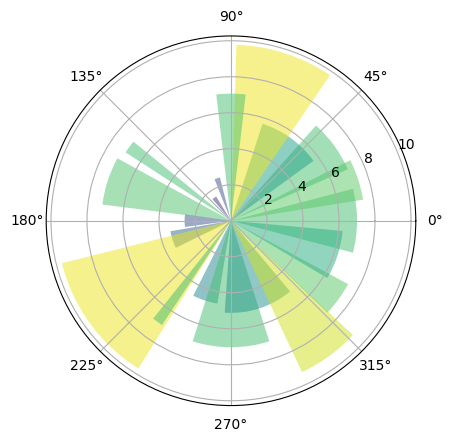

In [58]:
# From: https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_bar.html
"""
=======================
Pie chart on polar axis
=======================

Demo of bar plot on a polar axis.
"""
import numpy as np
import matplotlib.pyplot as plt


# Fixing random state for reproducibility
np.random.seed(19680801)

# Compute pie slices
N = 20
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = 10 * np.random.rand(N)
width = np.pi / 4 * np.random.rand(N)
colors = plt.cm.viridis(radii / 10.)

ax = plt.subplot(projection='polar')
ax.bar(theta, radii, width=width, bottom=0.0, color=colors, alpha=0.5)

plt.show()

---
## Converting from linkage matrix to tree

Understanding linkage matrices and trees can be a little tricky.

Let's look at the random data again, but this time with fewer points so that we can explore the linkage (Z) matrix a bit more easily. 

Text(0, 0.5, 'y [no units]')

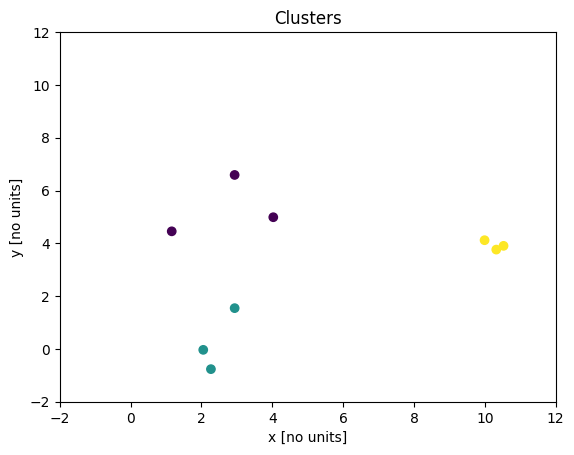

In [59]:
np.random.seed(12345678)

# lists for x and y coordinates of clusters, 
# as well as labels that have cluster numbers
x = []
y = []
cluster_labels = []

# number of clusters in dataset
n_clusters = 3

# points per cluster in dataset
n_pts_per_cluster = 3

# cluster distribution standard deviation size (arbitrary units - x and y limits are [0,10] in random number generation)
# sigma = 
sigma = 1.0


for this_cluster in range(n_clusters):
    ccx = 10*np.random.random()
    ccy = 10*np.random.random()

    for points in range(n_pts_per_cluster):
        x.append( ccx + np.random.normal(scale=sigma))
        y.append( ccy + np.random.normal(scale=sigma))
        cluster_labels.append(this_cluster)

plt.scatter(x,y,c=cluster_labels)
plt.xlim(-2,12)
plt.ylim(-2,12)
plt.title("Clusters")
plt.xlabel("x [no units]")
plt.ylabel("y [no units]")

## Inspecting a linkage matrix

We'll take this much smaller set and generate the linkage matrix and take a look at it. You should find that index `6` and `8` get linked and then index `7` gets linked to index "`9`" which goes beyond the number of points we have and there for represents the first entry in the linkage matrix. This means that index `7` has been linked to the combined link of "`6`-`8`". Feel free to create another dendogram to convince yourself that this is true.

In [60]:
combined_array = np.array([x,y])
links = linkage(combined_array.T, method='ward')
links

array([[ 6.        ,  8.        ,  0.24959384,  2.        ],
       [ 7.        ,  9.        ,  0.59816769,  3.        ],
       [ 4.        ,  5.        ,  0.76219202,  2.        ],
       [ 1.        ,  2.        ,  1.93774627,  2.        ],
       [ 3.        , 11.        ,  2.41912909,  3.        ],
       [ 0.        , 12.        ,  3.09142729,  3.        ],
       [13.        , 14.        ,  8.84140815,  6.        ],
       [10.        , 15.        , 15.59818521,  9.        ]])

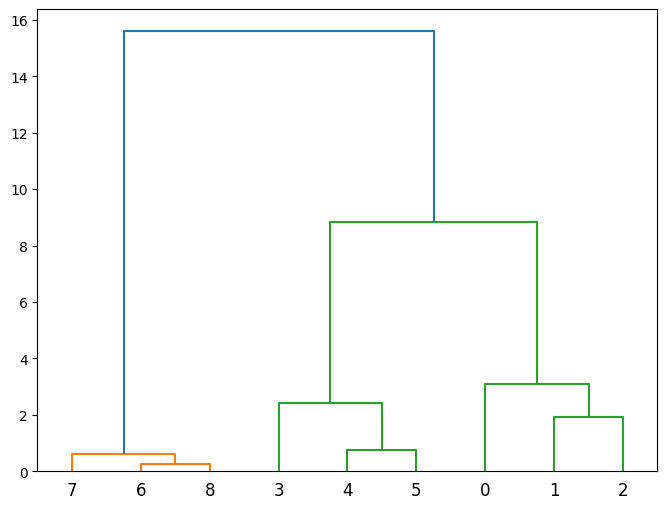

In [62]:
plt.figure(figsize=(8,6))
dendrogram(links)
plt.show()

## Generating a "ClusterNode" object from the linkage matrix

It turns out SciPy has a ["to_tree"](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.to_tree.html#scipy.cluster.hierarchy.to_tree) function that allows you to convert a linkage matrix to a "ClusterNode" (i.e. a tree) object, which can make creating your own visualizations easier. Review the code below and make sure you understand it.

In [63]:
from scipy.cluster import hierarchy

tree = hierarchy.to_tree(links)
type(tree)

scipy.cluster.hierarchy.ClusterNode

In [67]:
# Which is the id of the root node?
print("Root ID:",tree.id)

# How many elements are in our tree?
print("Tree has %i elements" %tree.count)

# Is this node a leaf (i.e. is it the end of a branch?)
print("Is this node a leaf?",tree.is_leaf())

# Which node is to the right and to the left of the root?
print("To the right:", tree.get_right().id)
print("To the left:", tree.get_left().id)

# We can do the same thing using the attributes directly:
print("To the right:", tree.right.id)
print("To the left:", tree.left.id)

# We can also dive deeper through the tree,
# but we need to be careful about
# what happens when we get to the end
print("If we go to the end, we find:", tree.right.right.right.right.get_right())

#The end should be a leaf...
print("Is the last node on the right a leaf?",tree.right.right.right.right.is_leaf())

Root ID: 16
Tree has 9 elements
Is this node a leaf? False
To the right: 15
To the left: 10
To the right: 15
To the left: 10
If we go to the end, we find: None
Is the last node on the right a leaf? True
